# Gráficos en escala logaritmica

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
path_mediciones = r"..\mediciones\clase1\clean\mediciones1_clean.csv"
mediciones = pd.read_csv(path_mediciones)

In [3]:
mediciones.head()

,vpp,vpp_error,10 Hz,100 Hz,1 KHz,10 KHz,100 KHz,1 MHz,vt_error
0,2.04,0.06,0.43,0.63,0.60,0.43,0.02,0.010,0.01
1,4.00,0.10,1.25,1.34,1.28,1.54,0.24,0.003,0.01
2,6.00,0.20,2.04,2.11,2.01,2.73,1.06,0.003,0.01
3,8.00,0.20,2.82,2.79,2.68,3.91,1.61,0.002,0.01
4,10.00,0.30,3.58,3.54,3.43,5.03,1.87,0.002,0.01


In [8]:
frecuencias = np.array([10, 100, 1E3, 10E3, 100E3, 1E6])
frecuencias

array([1.e+01, 1.e+02, 1.e+03, 1.e+04, 1.e+05, 1.e+06])

In [21]:
mediciones.loc[mediciones['vpp'] == 10.0, '10 Hz':'1 MHz']

,10 Hz,100 Hz,1 KHz,10 KHz,100 KHz,1 MHz
4,3.58,3.54,3.43,5.03,1.87,0.002


In [40]:
mediciones.loc[mediciones['vpp'] == 10.0, '10 Hz' : '1 MHz'].to_numpy().flatten()

array([3.58e+00, 3.54e+00, 3.43e+00, 5.03e+00, 1.87e+00, 2.00e-03])

In [31]:
mediciones.loc[mediciones['vpp'] == 10.0, 'vpp_error'].values[0]

np.float64(0.3)

In [41]:
vt10 = mediciones.loc[mediciones['vpp'] == 10.0, '10 Hz' : '1 MHz'].to_numpy().flatten()

In [35]:
vpp10_error = mediciones.loc[mediciones['vpp'] == 10.0, 'vpp_error'].values[0]
vpp10_error

np.float64(0.3)

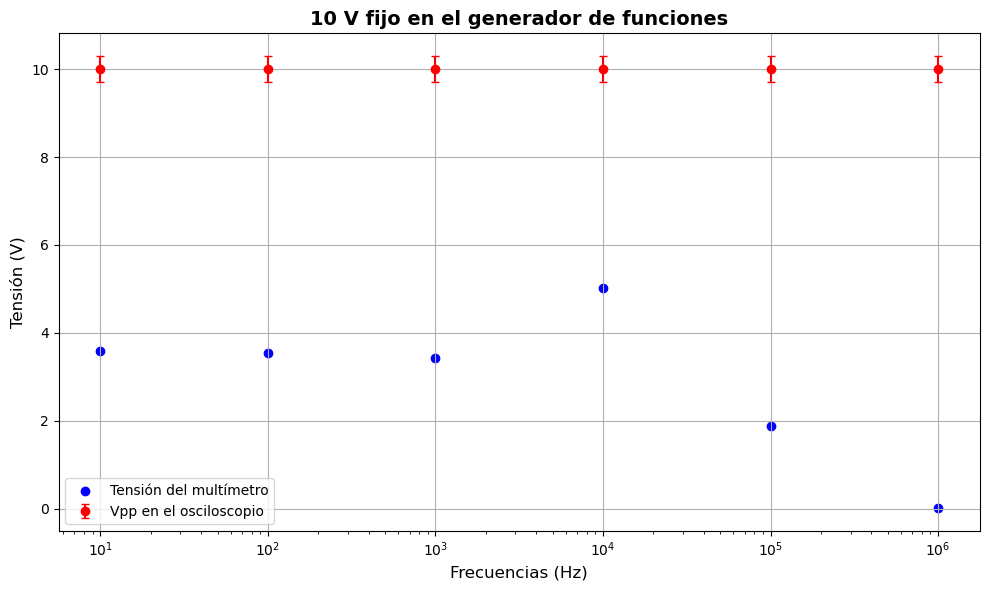

In [47]:
plt.figure(figsize=(10, 6))

plt.errorbar(
    x=frecuencias,
    y=np.full(6, 10.0),
    yerr=np.full(6, vpp10_error),
    fmt='o',
    capsize=3,
    color='red',
    label='Vpp en el osciloscopio'
)
plt.scatter(x=frecuencias,
            y=vt10,
            color='blue',
            label='Tensión del multímetro'
            )

plt.title("10 V fijo en el generador de funciones", fontsize=14, fontweight='bold')
plt.xlabel("Frecuencias (Hz)", fontsize=12)
plt.ylabel("Tensión (V)", fontsize=12)
plt.xscale('log')
plt.grid()
plt.legend()
plt.tight_layout()

# guardamos 
path_save = r".\clase1\obs_10v_log.png"
plt.savefig(path_save, dpi=300, bbox_inches='tight')

plt.show()